<a href="https://colab.research.google.com/github/shubhammadane/Deep-Learning-Project/blob/main/perceptron_trick_Shubham_Madane.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
# Import necessary libraries
from sklearn.datasets import make_classification # Used to generate synthetic datasets for classification
import numpy as np # Used for numerical operations, especially with arrays

# Generate a synthetic dataset for binary classification
# n_samples: total number of samples
# n_features: total number of features (X will have this many columns)
# n_informative: number of informative features (features that actually contribute to the class separation)
# n_redundant: number of redundant features (linear combinations of informative features)
# n_classes: number of classes (binary classification in this case)
# n_clusters_per_class: number of clusters each class is composed of
# random_state: seed for reproducibility
# hypercube: if True, samples are drawn from a hypercube. If False, samples are drawn from a Gaussian.
# class_sep: how separated the classes are
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [44]:
# Display the features (input data) X
X

array([[ 0.19924745, -0.11697552],
       [-0.24882029, -0.73115232],
       [-0.3544904 , -0.7081059 ],
       [-1.59086506, -2.01199214],
       [-0.20083951,  1.63493163],
       [-0.83241122,  0.15599044],
       [-1.79207014,  1.07782053],
       [ 0.0856607 ,  0.80626713],
       [-0.55865299,  0.74859527],
       [-1.95974262,  0.75152794],
       [-1.77828947, -0.90114581],
       [-1.77985853, -0.1815243 ],
       [-0.02194151, -2.98092432],
       [ 0.80563431,  1.20500136],
       [-1.82701214,  0.78302407],
       [ 0.38730728,  0.42968688],
       [-0.14108668, -0.73229726],
       [-1.87955941, -0.83930476],
       [-0.18232911,  0.83727062],
       [-1.77059533, -0.10255323],
       [-2.27658028,  0.65867001],
       [-2.06519502,  0.92649819],
       [-1.31690551,  0.10216193],
       [ 1.61043259,  0.46886454],
       [-1.21650394,  0.45432938],
       [ 0.6139723 ,  1.8613386 ],
       [-1.78760957, -0.79255991],
       [-1.04149161, -1.0004391 ],
       [-2.40067584,

In [45]:
# Display the target labels (output data) y
y

array([1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

In [46]:
# Demonstrate inserting a column of ones at the beginning of X
# This is typically done to add a bias term (x0 = 1) to the features for models like Perceptron.
# The '0' indicates insertion at index 0 (the first column).
# The '1' is the value to insert.
# 'axis=1' specifies that the insertion should be along the columns.
np.insert(X,0,1,axis=1)

array([[ 1.        ,  0.19924745, -0.11697552],
       [ 1.        , -0.24882029, -0.73115232],
       [ 1.        , -0.3544904 , -0.7081059 ],
       [ 1.        , -1.59086506, -2.01199214],
       [ 1.        , -0.20083951,  1.63493163],
       [ 1.        , -0.83241122,  0.15599044],
       [ 1.        , -1.79207014,  1.07782053],
       [ 1.        ,  0.0856607 ,  0.80626713],
       [ 1.        , -0.55865299,  0.74859527],
       [ 1.        , -1.95974262,  0.75152794],
       [ 1.        , -1.77828947, -0.90114581],
       [ 1.        , -1.77985853, -0.1815243 ],
       [ 1.        , -0.02194151, -2.98092432],
       [ 1.        ,  0.80563431,  1.20500136],
       [ 1.        , -1.82701214,  0.78302407],
       [ 1.        ,  0.38730728,  0.42968688],
       [ 1.        , -0.14108668, -0.73229726],
       [ 1.        , -1.87955941, -0.83930476],
       [ 1.        , -0.18232911,  0.83727062],
       [ 1.        , -1.77059533, -0.10255323],
       [ 1.        , -2.27658028,  0.658

In [47]:
# Display the shape of the features matrix X (number of rows, number of columns)
X.shape

(100, 2)

In [48]:
# Import the matplotlib library for plotting, aliased as 'plt'
import matplotlib.pyplot as plt

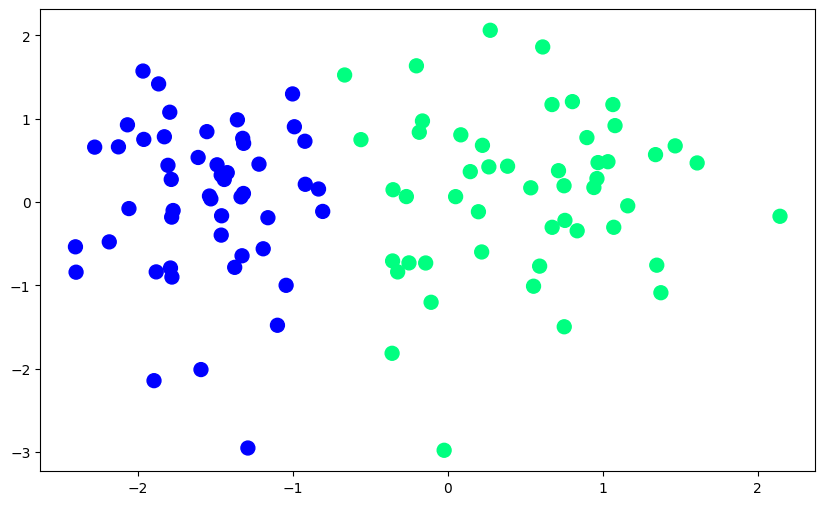

In [49]:
# Create a new figure with a specified size (width=10 inches, height=6 inches)
plt.figure(figsize=(10,6))
# Create a scatter plot of the data points
# X[:,0]: all rows, first column of X (feature 1)
# X[:,1]: all rows, second column of X (feature 2)
# c=y: color the points according to their class labels in 'y'
# cmap='winter': use the 'winter' colormap for coloring
# s=100: set the size of the markers to 100
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [50]:
# Define the Perceptron algorithm function
def perceptron(X,y):

    # Insert a column of ones at the beginning of X to account for the bias term (x0 = 1)
    # This allows the bias to be treated as another weight in the dot product.
    X = np.insert(X,0,1,axis=1)
    # Initialize weights: one weight for each feature (including the bias term)
    # All weights are initialized to 1.0
    weights = np.ones(X.shape[1])
    # Set the learning rate, which controls the step size during weight updates
    lr = 0.1

    # Iterate 1000 times to update the weights (epochs)
    for i in range(1000):
        # Randomly select an index 'j' to pick a data point for stochastic gradient descent
        j = np.random.randint(0,100)
        # Calculate the predicted output (y_hat) for the selected data point
        # np.dot(X[j],weights) computes the weighted sum of inputs for the j-th sample.
        # step() applies the activation function (heaviside step function) to get a binary output.
        y_hat = step(np.dot(X[j],weights))
        # Update the weights based on the prediction error (y[j] - y_hat)
        # This is the perceptron learning rule: weights = weights + learning_rate * (actual_output - predicted_output) * input_features
        weights = weights + lr*(y[j]-y_hat)*X[j]

    # Return the intercept (first weight, corresponding to the bias term) and the feature coefficients (remaining weights)
    return weights[0],weights[1:]

In [51]:
# Demonstrate initializing a NumPy array of ones with a specified size (3 elements)
np.ones( 3)

array([1., 1., 1.])

In [52]:
# Demonstrate generating a random integer between 0 (inclusive) and 100 (exclusive)
np.random.randint(0,100)

10

In [53]:
# Display the 98th data point (features) from the dataset X
X[98]

array([ 0.83626582, -0.34574201])

In [54]:
# Demonstrate a dot product calculation
# np.insert(X[98],0,1): inserts '1' at the beginning of the 98th data point, simulating adding a bias term
# [1,1,1]: an array used for the dot product, representing initial weights for example
# The dot product calculates the weighted sum of the (modified) input features.
np.dot(np.insert(X[98],0,1),[1,1,1])

np.float64(1.4905238177390734)

In [55]:
# Call the 'step' activation function with an input value of 1.490
# This will return 1 if 1.490 > 0, otherwise 0.
step(1.490)

1

In [56]:
# Define the step (Heaviside) activation function
# This function returns 1 if the input 'z' is greater than 0, otherwise it returns 0.
def step(z):
    return 1 if z>0 else 0

In [57]:
# Display the target label for the 98th data point from the dataset y
y[98]

np.int64(1)

In [58]:
# Run the perceptron algorithm to train the model
# The function returns the learned intercept (bias) and coefficients (weights for features)
intercept_,coef_ = perceptron(X,y)

In [59]:
# Print the learned coefficients (weights for the features)
print(coef_)
# Print the learned intercept (bias term)
print(intercept_)

[1.26328186 0.11145291]
1.0


In [60]:
# Calculate the slope (m) of the decision boundary line
# For a linear boundary defined by w0 + w1*x1 + w2*x2 = 0, the slope is -w1/w2
m = -(coef_[0]/coef_[1])
# Calculate the y-intercept (b) of the decision boundary line
# For the same boundary, the y-intercept is -w0/w2
b = -(intercept_/coef_[1])

In [61]:
# Generate 100 evenly spaced points between -3 and 3 for the x-axis of the decision boundary line
x_input = np.linspace(-3,3,100)
# Calculate the corresponding y-values for the decision boundary line using the learned slope 'm' and y-intercept 'b'
y_input = m*x_input + b

(-3.0, 2.0)

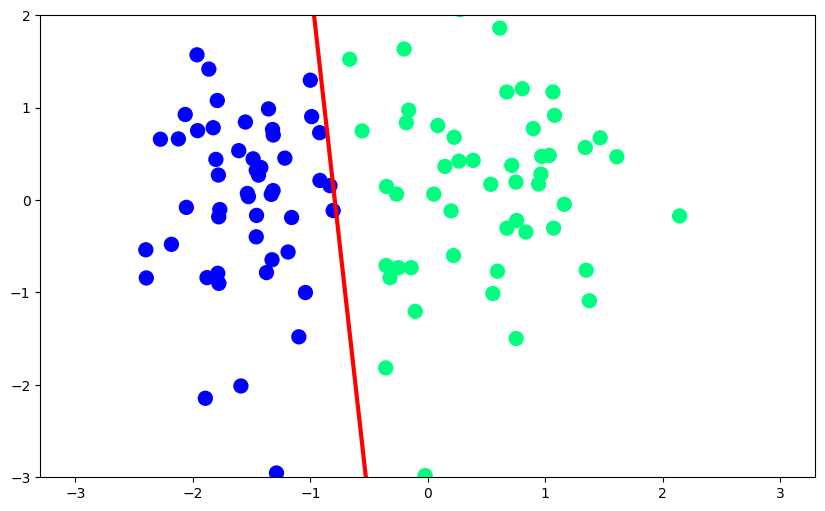

In [62]:
# Create a new figure with a specified size
plt.figure(figsize=(10,6))
# Plot the decision boundary line
# x_input: x-coordinates for the line
# y_input: y-coordinates for the line
# color='red': set the line color to red
# linewidth=3: set the line width to 3 pixels
plt.plot(x_input,y_input,color='red',linewidth=3)
# Plot the original data points as a scatter plot
# X[:,0]: first feature
# X[:,1]: second feature
# c=y: color points by their class labels
# cmap='winter': use 'winter' colormap
# s=100: set marker size
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
# Set the y-axis limits to -3 and 2 to ensure the plot is well-framed
plt.ylim(-3,2)